In [1]:
#GA and NM Hybrid

Generation 150, Best Fitness: 0.3913751058350689
Current Average Probability: 0.16695055576588072
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.3785228234864263
Current Average Probability: 0.21151472931180723
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.36781258819589074
Current Average Probability: 0.2690871614783553
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.33951931218082226
Current Average Probability: 0.2950694067598138
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.351105720007309
Current Average Probability: 0.3486495943070354
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.2943653386734884
Current Average Probability: 0.33033628304739987
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.31155160757974276
Current Average Probability: 0.3558765277366508
Added a new camera to improve coverage.
Generation 150, Best Fitness: 0.2932

<Figure size 1200x800 with 0 Axes>

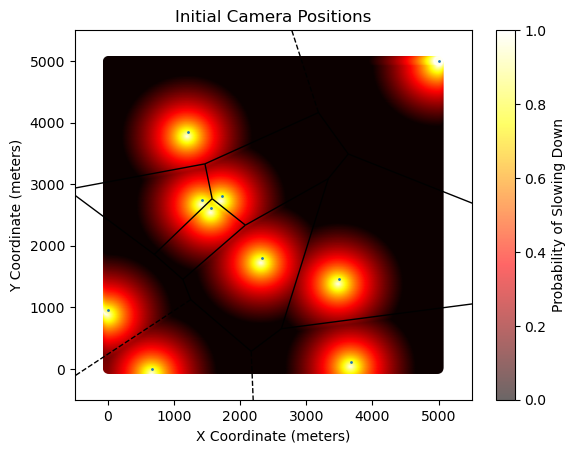

Initial Average Coverage Probability: 0.09986488416727872


<Figure size 1200x800 with 0 Axes>

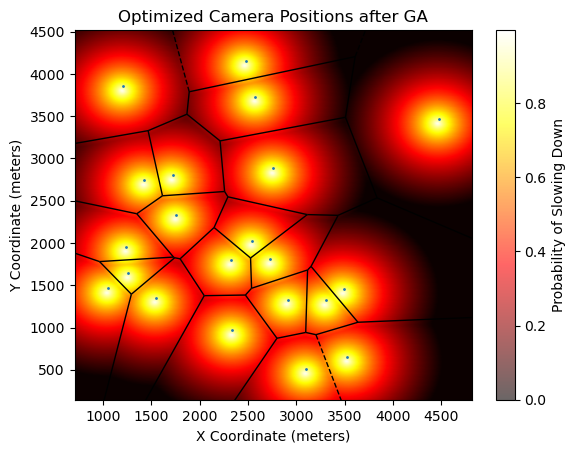

Optimized Average Coverage Probability: 0.420841104503345

Solution Improvement: 3.214104968052783


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon


# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'LAS CONDES']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.5176279) & (provi_df['Y'].round(7) == -33.3727704))]
provi_df = provi_df[~((provi_df['X'].round(7) == -70.5339428) & (provi_df['Y'].round(7) == -33.3840674))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 500


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 300
num_generations = 150
mutation_base_rate = 0.02
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 10
num_parents = population_size // 2
early_stopping_rounds = num_generations
no_improvement_stretch = 0
best_fitness = 0
elitism_count = int(0.05 * population_size)  # 5% of the population size


# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()

# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)



def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            new_position = np.random.uniform(0, max(area_size), 2)
            while np.any(np.all(np.isclose(child, new_position, atol=0.1), axis=1)):  # Check if the new position is too close to existing ones
                new_position = np.random.uniform(0, max(area_size), 2)
            child[i] = new_position
    return child



def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=1.0):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0

    # Check for duplicate positions
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            if np.linalg.norm(individual[i] - individual[j]) < 10:  # Very close cameras
                penalty += 1

    # Apply a heavy penalty for duplicates
    adjusted_coverage = coverage - penalty_scale * penalty

    # Ensure fitness is non-negative
    return max(0, adjusted_coverage)





def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

def check_and_add_camera(best_solution, grid_points):
    current_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
    print(f"Current Average Probability: {current_avg_probability}")
    if current_avg_probability < desired_probability_threshold:
        # Add a new camera at a random location within the area
        new_camera_position = np.array([[np.random.uniform(0, area_size[0]), np.random.uniform(0, area_size[1])]])
        updated_solution = np.vstack([best_solution, new_camera_position])
        print("Added a new camera to improve coverage.")
        return updated_solution
    else:
        return None


# Initialize population
population = initialize_population(population_size, scaled_crash_points)
desired_probability_threshold = 0.4  # Set your desired threshold here

#--------------------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------

# Main GA loop modifications
while True:
    for generation in range(num_generations):
        fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
        current_best = np.max(fitness_scores)
    
        if current_best > best_fitness:
            best_fitness = current_best
            no_improvement_stretch = 0
        else:
            no_improvement_stretch += 1
    
        if no_improvement_stretch >= early_stopping_rounds:
            print(f"Early stopping after {generation} generations.")
            break
    
    # Select the elite individuals
    elite_indices = np.argsort(-fitness_scores)[:elitism_count]  # Negative for descending order
    elites = [population[i] for i in elite_indices]
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

    # Evaluate the best solution
    final_fitness_scores = calculate_fitness(population, grid_points, min_distance)
    best_index = np.argmax(final_fitness_scores)
    best_solution = population[best_index]

    # Check and possibly add a new camera
    updated_solution = check_and_add_camera(best_solution, grid_points)
    if updated_solution is not None:
        population = initialize_population(population_size, updated_solution)
        best_fitness = 0  # Reset the best fitness
        no_improvement_stretch = 0  # Reset the counter
    else:
        print("No need to add more cameras.")
        break
    
#-----------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------

scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions after GA')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

# Initialize camera positions with scaled crash points
camera_positions = best_solution

# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
ga_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
ga_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)



In [3]:
#---------------------------------------------------------------------------------------------------------------------
#NM
#---------------------------------------------------------------------------------------------------------------------------------

Optimized Average Coverage Probability: 0.4641492756199823


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_9203/1351094459.py:13: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


<Figure size 1200x800 with 0 Axes>

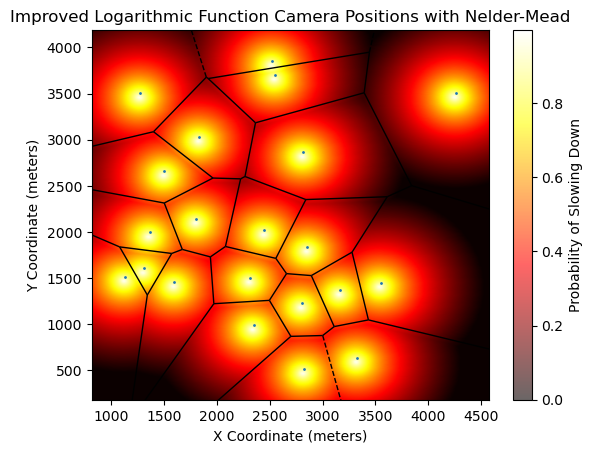

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.57, Y: -33.42)
Camera 2: (X: -70.57, Y: -33.40)
Camera 3: (X: -70.56, Y: -33.42)
Camera 4: (X: -70.57, Y: -33.41)
Camera 5: (X: -70.57, Y: -33.42)
Camera 6: (X: -70.55, Y: -33.43)
Camera 7: (X: -70.57, Y: -33.42)
Camera 8: (X: -70.55, Y: -33.40)
Camera 9: (X: -70.56, Y: -33.42)
Camera 10: (X: -70.56, Y: -33.42)
Camera 11: (X: -70.57, Y: -33.42)
Camera 12: (X: -70.56, Y: -33.42)
Camera 13: (X: -70.55, Y: -33.42)
Camera 14: (X: -70.56, Y: -33.40)
Camera 15: (X: -70.56, Y: -33.41)
Camera 16: (X: -70.56, Y: -33.41)
Camera 17: (X: -70.56, Y: -33.40)
Camera 18: (X: -70.57, Y: -33.41)
Camera 19: (X: -70.57, Y: -33.41)
Camera 20: (X: -70.56, Y: -33.43)
Camera 21: (X: -70.56, Y: -33.42)


<Figure size 1200x800 with 0 Axes>

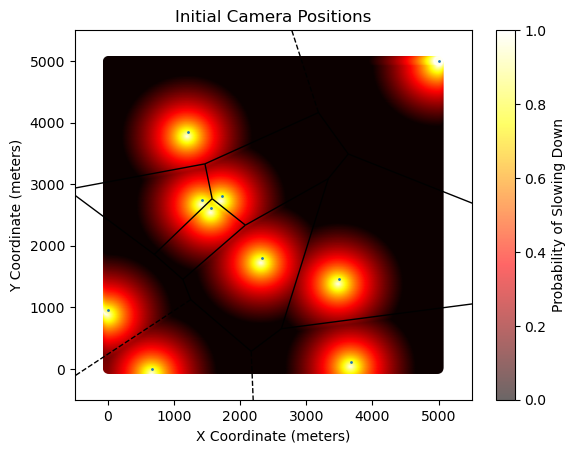

Initial Average Coverage Probability: 0.09986488416727872


<Figure size 1200x800 with 0 Axes>

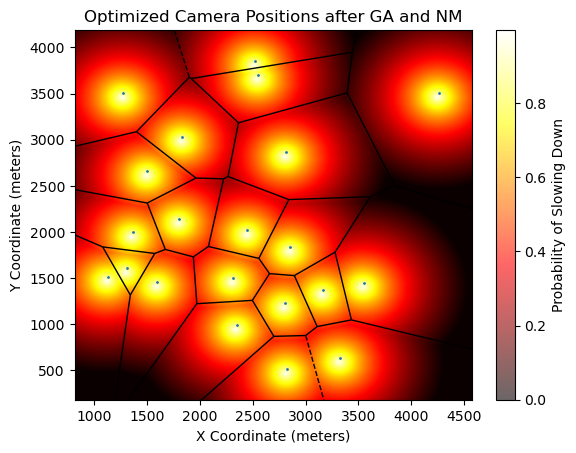

Optimized Average Coverage Probability after GA and NM: 0.4641492756199823

Solution Improvement: 3.647772632895752


In [4]:

# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

#Nelder-Mead Optimization after GA----------------------------------------------------------------------
camera_positions = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)



In [5]:
#Save the solution----------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
output_csv_path = '/Users/sebi/Desktop/Hybrid_Log_LasCondes_Positions.csv'  # Adjust the path as necessary
camera_positions_df.to_csv(output_csv_path, index=False)

<Figure size 1200x800 with 0 Axes>

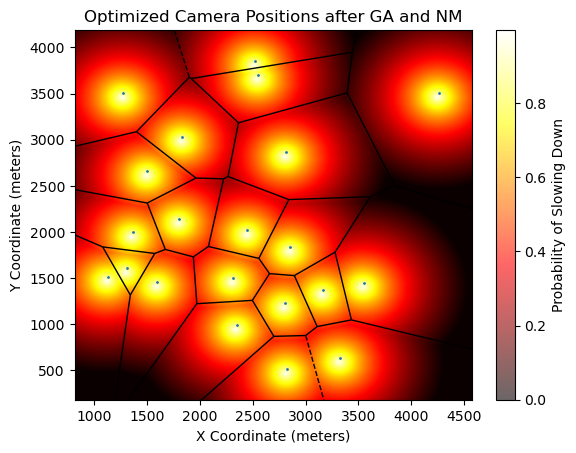

Optimized Average Coverage Probability after GA and NM: 0.4641492756199823



In [8]:
# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]
distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(optimized_camera_positions, probabilities, 'Optimized Camera Positions after GA and NM')
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability after GA and NM: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print("")